Shapley Values Tutorial
------------------------

Welcome, during this ungraded lab you are going to be working with SHAP (SHapley Additive exPlanations). This procedure is derived from game theory and aims to understand (or explain) the output of any machine learning model. In particular you will:


1. Train a simple CNN on the fashion mnist dataset.
2. Compute the Shapley values for examples of each class.
3. Visualize these values and derive information from them.

To learn more about Shapley Values visit the official [SHAP repo](https://github.com/slundberg/shap).

Let's get started!


## Imports

Begin by installing the shap library:



In [1]:
!pip install shap

Now import all necessary dependencies:

In [2]:
import shap
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

## Train a CNN model

For this lab you will use the [fashion MNIST](https://keras.io/api/datasets/fashion_mnist/) dataset. Load it and pre-process the data before feeding it into the model:


In [3]:
# Download the dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Reshape and normalize data
x_train = x_train.reshape(60000, 28, 28, 1).astype("float32") / 255
x_test = x_test.reshape(10000, 28, 28, 1).astype("float32") / 255

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


For the CNN model you will use a simple architecture composed of a single  convolutional and maxpooling layers pair connected to a fully conected layer with 256 units and the output layer with 10 units since there are 10 categories.

Define the model using Keras' [Functional API](https://keras.io/guides/functional_api/):


In [4]:
# Define the model architecture using the functional API
inputs = keras.Input(shape=(28, 28, 1))
x = keras.layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation='relu')(x)
outputs = keras.layers.Dense(10, activation='softmax')(x)

# Create the model with the corresponding inputs and outputs
model = keras.Model(inputs=inputs, outputs=outputs, name="CNN")

# Compile the model
model.compile(
      loss=tf.keras.losses.SparseCategoricalCrossentropy(),
      optimizer=keras.optimizers.Adam(),
      metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
  )

# Train it!
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 0.4950 - sparse_categorical_accuracy: 0.8239 - val_loss: 0.3272 - val_sparse_categorical_accuracy: 0.8756
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2574 - sparse_categorical_accuracy: 0.9069 - val_loss: 0.2647 - val_sparse_categorical_accuracy: 0.9029
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2073 - sparse_categorical_accuracy: 0.9234 - val_loss: 0.2394 - val_sparse_categorical_accuracy: 0.9133
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.1659 - sparse_categorical_accuracy: 0.9396 - val_loss: 0.2505 - val_sparse_categorical_accuracy: 0.9113
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.1345 - sparse_categorical_accuracy: 0.9502 - val_loss: 0.2847 - val_sparse_categorical_accuracy: 0.9024


Judging the accuracy metrics looks like the model is overfitting. However, it is achieving a >90% accuracy on the test set so its performance is adequate for the purposes of this lab.

# Explaining the outputs

You know that the model is correctly classifying around 90% of the images in the test set. But
how is it doing it? What pixels are being used to determine if an image belongs to a particular
class?

To answer these questions you can use SHAP values.

**How is this different from the tabular SHAP example you may have seen before?** With a
spreadsheet of customer data, each *feature* (e.g. `monthly_charges`) gets one SHAP value. With
an image, there's no spreadsheet of named columns — instead, **every single pixel is treated as
its own "feature."** A 28×28 image has 784 pixels, so SHAP computes 784 individual SHAP values
per image (one per pixel) — for *each* of the 10 possible clothing classes. That's why the
visualizations later look like heatmaps overlaid on the image, rather than bar charts: color at
each pixel location tells you how much that pixel pushed the model toward (or away from)
predicting a particular class.

Before doing so, check how each one of the categories looks like:


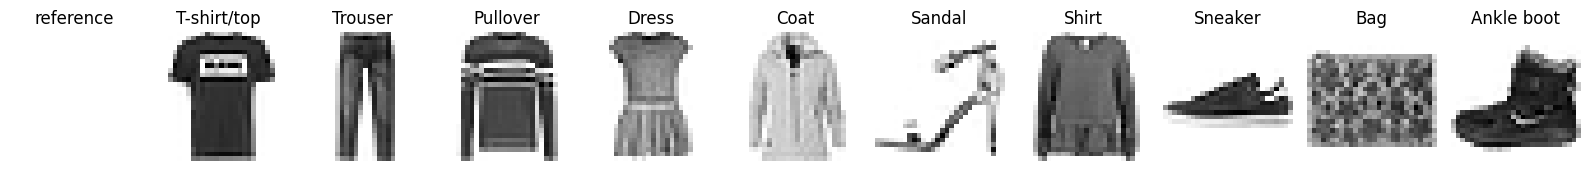

In [5]:
# Name each one of the classes
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Save an example for each category in a dict
images_dict = dict()
for i, l in enumerate(y_train):
  if len(images_dict)==10:
    break
  if l not in images_dict.keys():
    images_dict[l] = x_train[i].reshape((28, 28))

# Function to plot images
def plot_categories(images):
  fig, axes = plt.subplots(1, 11, figsize=(16, 15))
  axes = axes.flatten()

  # Plot an empty canvas
  ax = axes[0]
  dummy_array = np.array([[[0, 0, 0, 0]]], dtype='uint8')
  ax.set_title("reference")
  ax.set_axis_off()
  ax.imshow(dummy_array, interpolation='nearest')

  # Plot an image for every category
  for k,v in images.items():
    ax = axes[k+1]
    ax.imshow(v, cmap=plt.cm.binary)
    ax.set_title(f"{class_names[k]}")
    ax.set_axis_off()

  plt.tight_layout()
  plt.show()


# Use the function to plot
plot_categories(images_dict)

Now you know how the items in each one of the categories looks like.

You might wonder what the empty image at the left is for. You will see shortly why it is important.

## DeepExplainer

To compute shap values for the model you just trained you will use the `DeepExplainer` class
from the `shap` library.

**Why not `TreeExplainer`?** `TreeExplainer` only works for tree-based models (Random Forest,
XGBoost, etc). Our CNN is a neural network, so we need an explainer built for that —
`DeepExplainer` uses a fast, gradient-based approximation method (related to a technique called
DeepLIFT) to estimate SHAP values for deep learning models. It's not an exact calculation like
`TreeExplainer`'s, but it's an efficient, accurate-enough approximation that scales well to
image-sized inputs.

**What's this "background" for?** SHAP always needs a reference point to compare against — the
question a SHAP value answers is *"how did this pixel change the prediction, compared to
not knowing this pixel's value?"* The "background" is a small, random sample of training images
that stands in for "typical, uninformative input." `DeepExplainer` uses it to estimate what the
model would predict if it only had "average" information — as its baseline before adding in the
specific pixels of the image you actually want to explain.

To instantiate this class you need to pass in a model along with training examples. Notice that
not all of the training examples are passed in but only a fraction of them.

This is done because the computations done by the `DeepExplainer` object are very intensive on
the RAM and you might run out of it.


In [13]:
# Take a random sample of 500 training images to use as the SHAP "background"
# (Note: DeepExplainer needs a background dataset to represent "what a typical
# input looks like" — see the explanation above. 500 is a deliberate trade-off:
# more background images gives more stable/accurate SHAP values, but the cost
# of computing SHAP values scales with background size, and this computation
# is memory- and compute-intensive. 500 is a reasonable balance for a live demo.)
background = x_train[np.random.choice(x_train.shape[0], 500, replace=False)]

# Use DeepExplainer to explain predictions of the model
e = shap.DeepExplainer(model, background)

# Compute shap values
# shap_values = e.shap_values(x_test[1:5])


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(500, 28, 28, 1))']
  warnings.warn(msg)


Now you can use the `DeepExplainer` instance to compute Shap values for images on the test
set.

So you can properly visualize these values for each class, create an array that contains one
element of each class from the test set. **Why one example per class, instead of just picking
10 random test images?** Because the visualization coming up in Section "Visualizing Shap
Values" arranges images in a grid — one row per image, one column per possible class — and it's
much easier to spot patterns (like "does the model's reasoning make sense?") when you know
exactly which true class each row belongs to.


In [14]:
# Save an example of each class from the test set
x_test_dict = dict()
for i, l in enumerate(y_test):
  if len(x_test_dict)==10:
    break
  if l not in x_test_dict.keys():
    x_test_dict[l] = x_test[i]

# Convert to list preserving order of classes
x_test_each_class = [x_test_dict[i] for i in sorted(x_test_dict)]

# Convert to tensor
x_test_each_class = np.asarray(x_test_each_class)

# Print shape of tensor
print(f"x_test_each_class tensor has shape: {x_test_each_class.shape}")

x_test_each_class tensor has shape: (10, 28, 28, 1)


Before computing the shap values, make sure that the model is able to correctly classify each one of the examples you just picked:

In [15]:
# Compute predictions
predictions = model.predict(x_test_each_class)

# Apply argmax to get predicted class
np.argmax(predictions, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Since the test examples are ordered according to the class number and the predictions array is also ordered, the model was able to correctly classify each one of these images.

## Visualizing Shap Values

Now that you have an example of each class, compute the Shap values for each example. This is
the computationally expensive step — for every one of the 10 test images, `DeepExplainer` will
estimate a SHAP value for every pixel, for every one of the 10 possible output classes. That's
`10 images × 784 pixels × 10 classes` = 78,400 individual numbers, all from one line of code.


In [16]:
# Compute shap values using DeepExplainer instance
# check_additivity=False avoids a spurious "Additivity check failed" error
# that can occur with recent TensorFlow versions due to tiny floating-point
# differences — it does not affect the correctness of the explanation.
shap_values = e.shap_values(x_test_each_class, check_additivity=False)

# --- IMPORTANT: SHAP-version compatibility fix ---
# In newer versions of the `shap` library (>=0.45 or so), DeepExplainer.shap_values()
# returns ONE stacked array of shape (samples, height, width, channels, num_classes)
# instead of the older format: a Python LIST of 10 separate arrays (one per class).
# shap.image_plot() (used in the next cell) still expects the OLD list format, so
# we convert here. If you're on an older shap version where shap_values is already
# a list, this conversion is skipped automatically.
if isinstance(shap_values, np.ndarray):
    shap_values = [shap_values[..., i] for i in range(shap_values.shape[-1])]

print(f"Number of class explanations: {len(shap_values)}")
print(f"Shape of each class's SHAP values: {shap_values[0].shape}")


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1000, 28, 28, 1))']
  warnings.warn(msg)


**📖 What am I looking at?** The printed output confirms the SHAP values are organized the
way the next plotting step expects: **10 separate arrays** (one per clothing class), each
holding SHAP values shaped `(10, 28, 28, 1)` — meaning "10 test images × 28×28 pixels × 1 color
channel (grayscale)." No plot yet — this cell just verifies the calculation finished with the
right shape before we visualize it.

> **Behind the scenes:** newer versions of the `shap` library return these values pre-packaged
> differently than older versions did (a single combined array instead of a list of 10
> separate ones). The code above automatically detects and converts either format, so this
> notebook keeps working regardless of which `shap` version Colab happens to have installed.


Now take a look at the computed shap values, plotted below. This grid is the main output of
this whole notebook, so let's go through it slowly and precisely.

**📖 How to read this grid, step by step:**

1. **The layout is a grid: one row per test image, one column per possible class.** With 10
   test images (one per clothing category) and 10 possible classes, you get a 10×10 grid of
   small heatmaps, plus one extra reference column on the far left showing the original image.
2. **Each row is labeled (implicitly) by which image it is.** Row 1 is the T-shirt/top test
   image, row 2 is the Trouser test image, and so on, in the same order as `class_names`.
3. **Each column is labeled with a class name** (e.g. "Coat," "Sandal") — that column answers
   the question *"which pixels made the model think THIS row's image belongs to THIS column's
   class?"*
4. **Color = the SHAP value at that pixel, for that row's image, for that column's class:**
   - 🔴 **Red pixels** have a **positive** SHAP value — that pixel's appearance pushed the
     model **toward** predicting the column's class for this image.
   - 🔵 **Blue pixels** have a **negative** SHAP value — that pixel's appearance pushed the
     model **away from** predicting the column's class.
   - **Faint/white pixels** are close to zero — that pixel barely mattered for this
     classification decision.
5. **The intensity (darkness/saturation) of the color = the size of that pixel's SHAP value.**
   A vivid, saturated red pixel had a much bigger influence than a pale pink one.
6. **Now look at the diagonal.** Since row 1 is a true T-shirt/top and column 1 is the
   "T-shirt/top" class, row 1 / column 1 is on the diagonal — and *should* show mostly red,
   since the model correctly predicted this class and the pixels genuinely support that
   prediction. The same logic applies to every row/column pair where the row's true class
   matches the column's class. **A strong red pattern down the diagonal is a good visual sign
   the model is "looking at the right evidence" for its correct predictions.**
7. **Off-diagonal columns are just as interesting.** A column that's mostly faint/white for a
   given row means "the model saw basically no evidence for that alternative class." A column
   that shows some red for a given row (even though it's not the predicted class) means "the
   model saw *some* resemblance to that class too" — which is exactly what we explore in the
   next section with the **coat** example.

Before diving into that example, keep these points in mind:
- Positive shap values are denoted by red color and they represent the pixels that contributed
  to classifying that image as that particular class.
- Negative shap values are denoted by blue color and they represent the pixels that contributed
  to NOT classify that image as that particular class.
- Each row contains each one of the test images you computed the shap values for.
- Each column represents the ordered categories that the model could choose from. Notice that
  `shap.image_plot` just makes a copy of the classified image, but you can use the
  `plot_categories` function you created earlier to show an example of that class for
  reference.


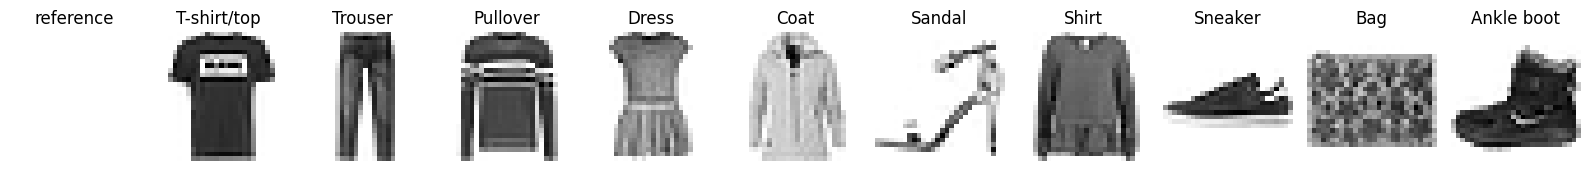

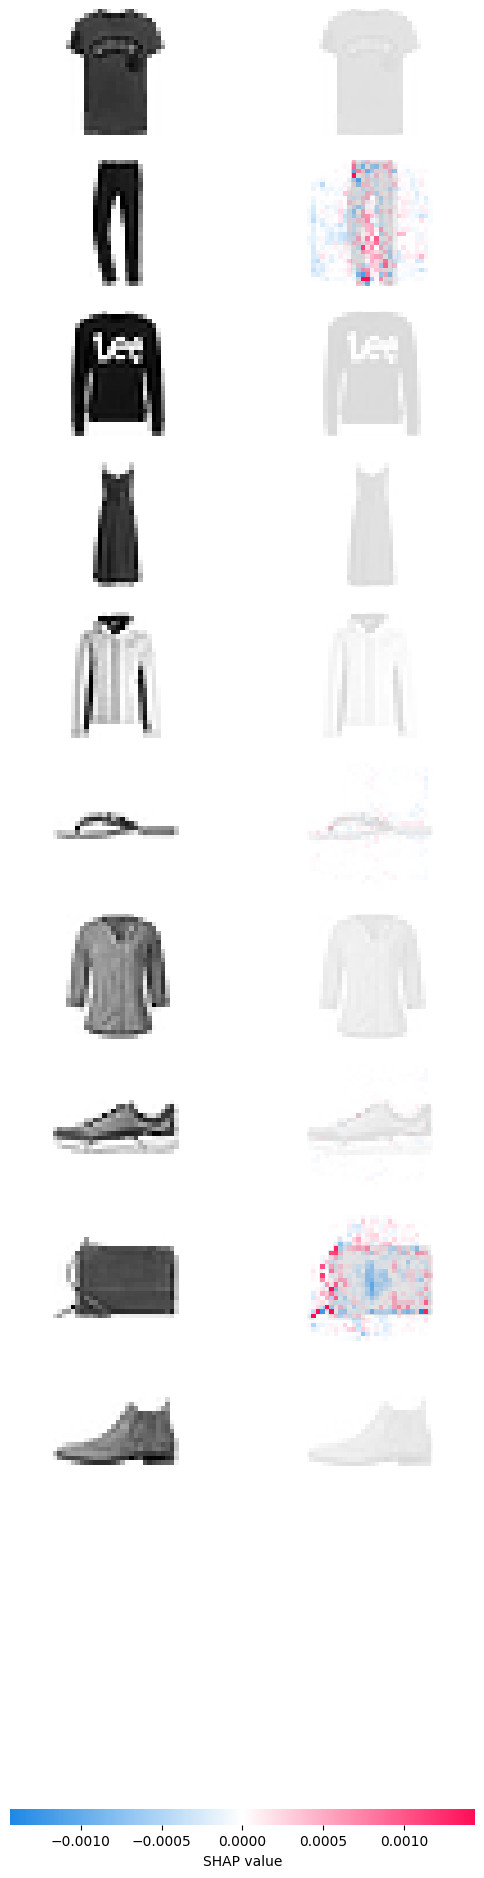

In [17]:
# Plot reference column
plot_categories(images_dict)

# Print an empty line to separate the two plots
print()

# Label each column with the actual class name instead of a bare number —
# makes the grid below much easier to read at a glance.
column_labels = np.tile(np.array(class_names), (x_test_each_class.shape[0], 1))

# Plot shap values
shap.image_plot(shap_values, -x_test_each_class, labels=column_labels)


Now take some time to understand what the plot is showing you.

**📖 Walking through a concrete example — the "coat" row, step by step:**

1. Since the model is able to correctly classify each one of these 10 images, it makes sense
   that the SHAP values along the diagonal are the most prevalent — specifically **positive**
   (red) values, since that's the class the model (correctly) predicted for each row.
2. **Now focus on one specific row: the Coat row** (the 5th row, since `class_names` is
   0-indexed and Coat is index 4). Scan across all 10 columns for this row.
3. You should notice the **Coat column** itself (the diagonal cell) is strongly red — expected,
   since the model correctly identified this image as a coat.
4. But look at the **Pullover** and **Shirt** columns for this same row — you should also see
   some **red** there too, just less intense than the diagonal cell. This is the interesting
   part: **it means the model saw some pixel-level evidence that this image resembles a
   pullover or a shirt as well** — it wasn't a slam-dunk, unambiguous "coat," even though that's
   the class it ultimately (and correctly) chose.
5. **Why would that be?** Coats, pullovers, and shirts are all upper-body garments with roughly
   similar overall silhouettes (long torso, sleeves) — much more visually similar to each other
   than, say, a coat is to a sandal or a bag. So it's genuinely reasonable for the model to have
   "noticed" some resemblance.

Let's take a look at the tensor of predictions to double check if this was the case:


In [12]:
# Save the probability of belonging to each class for the fifth element of the set
coat_probs = predictions[4]

# Order the probabilities in ascending order
coat_args = np.argsort(coat_probs)

# Reverse the list and get the top 3 probabilities
top_coat_args = coat_args[::-1][:3]

# Print (ordered) top 3 classes
for i in list(top_coat_args):
  print(class_names[i])

Coat
Pullover
Shirt


**📖 Confirming the pattern numerically:**

Indeed the model selected these 3 classes (Coat, Pullover, Shirt) as the most probable ones for
the **coat** image — exactly matching the columns that showed some red in the SHAP grid above.
This makes sense since these objects are visually similar to each other. This is a nice example
of SHAP and the model's own predicted probabilities **telling the same story from two different
angles**: the probabilities tell you the model's final confidence ranking, while SHAP tells you
*which specific pixels* drove that ranking.

**📖 A second example — T-shirt vs. Pullover, step by step:**

1. Now look at the **T-shirt/top** row (the 1st class). A T-shirt/top is visually very similar
   to a **Pullover**, with one key difference: pullovers have long sleeves, T-shirts don't.
2. Find the region of the image where long sleeves *would* be if this were a pullover — for a
   real T-shirt, those pixels are background (white/blank), not part of the garment.
3. **Look at the "T-shirt/top" column for this row**: you should see those sleeve-area pixels
   showing a positive (red) SHAP value. In plain English: *"the fact that these pixels are
   blank/background — not filled in with a sleeve — is evidence for T-shirt."*
4. **Now look at the "Pullover" column for the same row, same pixels**: you should see the
   opposite — a negative (blue) SHAP value in that same sleeve-area region. In plain English:
   *"the model expected a pullover to have colored-in pixels here (a sleeve); since they're
   blank, that counts as evidence AGAINST pullover."*
5. **The takeaway:** the exact same pixels, in the exact same location, can have **opposite**
   SHAP signs depending on which class's column you're looking at. This is one of the most
   important ideas in this whole notebook — a SHAP value is always *relative to one specific
   class's evidence*, not an absolute property of the pixel.

You can get a lot of insight repeating this process for all the classes. Try picking another
pair of visually similar classes (e.g. Sandal vs. Sneaker, or Shirt vs. Coat) and walk through
the same 5 steps above. What other conclusions can you arrive at?


-----------------------------
**Congratulations on finishing this ungraded lab!** Now you should have a clearer understanding
of what Shapley values are, why they are useful and how to compute them using the `shap`
library.

**Key takeaways:**

| Concept | What it means here |
|---|---|
| Unit of explanation | One SHAP value **per pixel, per class** (not per-feature like tabular data) |
| Positive (red) SHAP value | This pixel's appearance pushed the prediction **toward** that column's class |
| Negative (blue) SHAP value | This pixel's appearance pushed the prediction **away from** that column's class |
| Strong diagonal pattern | A good sign the model's correct predictions are backed by sensible pixel evidence |
| Off-diagonal red patches | The model saw partial resemblance to another class — often visually similar classes (coat/pullover/shirt) |
| Same pixel, different columns | The same pixel can have opposite-signed SHAP values across different class columns — SHAP is always "evidence for THIS specific class" |
| `DeepExplainer` vs `TreeExplainer` | Gradient-based approximation for neural networks, vs. exact computation for tree models |

Deep Learning models were considered black boxes for a very long time. There is a natural trade
off between predicting power and explanaibility in Machine Learning but thanks to the rise of
new techniques such as SHapley Additive exPlanations it is easier than never before to explain
the outputs of Deep Learning models.


**Keep it up!**
